Reaccion A-B A-C:


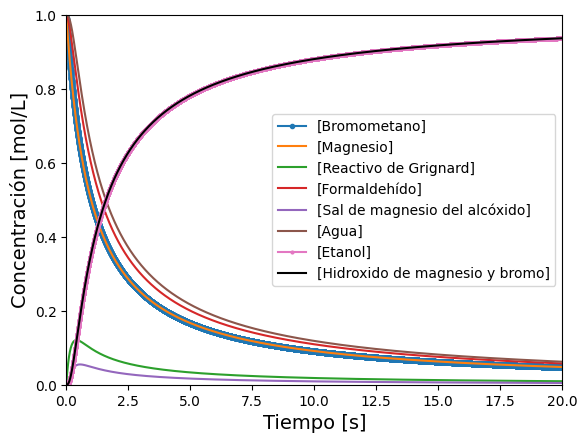

In [1]:
#!/usr/bin/env python

import numpy as np                #Se importa la librería numpy la cual puede ser llamada con np
import matplotlib.pyplot as plt  #Se importa la librería matplotlib.pyplot que puede ser llamada con plt.


print("Reaccion A-B A-C:")
#A0=float(input("Introducir el valor de A[t=0]: "))
#dt=float(input("Introducir el valor de dt(s): "))
#k1=float(input("Introducir el valor de k1: "))
#k2=float(input("Introducir el valor de k2: "))
#pasos=int(input("Introducir el numero de pasos: "))
#nombre=str(input("Introducir el nombre de la grafica final: "))

A0=1 #Concentración inicial de A (Bromometano)
B0=1 #Concentración inicial de B (magnesio)
D0=1 #Concentración inicial de D (Formaldehído)
F0=1 #Concentración inicial de F (Agua)
dt=.001   #Aquí se define el valor del paso de tiempo delta t
K1=1   #Valor de la constante K1
K2=5   #Valor de la constante K2
K3=10   #valor de la constante K3

pasos=20000    #Número de pasos de la simulación
nombre="Concentración en función del tiempo"

t=0
C=0
E=0
G=0
H=0
i=0
A=A0
B=B0
D=D0
F=F0
datos=np.array([[t,A,B,C,D,E,F,G,H]])

while i <=  pasos:
  t=t+dt
  i=i+1
  A=A+(-K1*A*B)*dt
  B=B+(-K1*A*B)*dt
  C=C+((K1*A*B)-(K2*C*D))*dt
  D=D+(-K2*C*D)*dt
  E=E+((K2*C*D)-(K3*E*F))*dt
  F=F+(-K3*E*F)*dt
  G=G+(K3*E*F)*dt
  H=H+(K3*E*F)*dt

#A continuacion se define una matriz con todos los datos y el tiempo
  datos=np.append(datos, [[t,A,B,C,D,E,F,G,H]],axis=0)

#Sigue la sección de guardar los datos
np.savetxt(nombre+".csv", datos, delimiter=",")
archivo=open(nombre+".csv","a+")
archivo.write("[A]0= "+str(A0)+"[B]0= "+str(B0)+"[D]0= "+str(D0)+"[F]0= "+str(F0)+" dt= "+str(dt)+" K1= "+str(K1)+" K2= "+str(K2)+" K3= "+str(K3))
archivo.close()

#Sigue la sección de graficación
plt.plot(figsize=(400,500))
plt.plot(datos[:,0],datos[:,1],label="[Bromometano]",marker='.')
plt.plot(datos[:,0],datos[:,2],label="[Magnesio]")
plt.plot(datos[:,0],datos[:,3],label="[Reactivo de Grignard]")
plt.plot(datos[:,0],datos[:,4],label="[Formaldehído]")
plt.plot(datos[:,0],datos[:,5],label="[Sal de magnesio del alcóxido]")
plt.plot(datos[:,0],datos[:,6],label="[Agua]")
plt.plot(datos[:,0],datos[:,7],label="[Etanol]",marker='.',markersize=4)
plt.plot(datos[:,0],datos[:,8],label="[Hidroxido de magnesio y bromo]",color="Black")

plt.xlabel("Tiempo [s]", fontsize=14)
plt.xlim([0,20])
plt.ylabel("Concentración [mol/L]", fontsize=14)
plt.ylim([0,1])
leg = plt.legend(loc='best', ncol=1, fancybox=True)
plt.savefig(nombre+".png",dpi=500)
plt.show()